# Urban Traffic Congestion Prediction and Analysis Using Machine Learning

## Project Overview

This project focuses on analyzing urban traffic patterns and developing a machine learning model to predict traffic volume based on factors such as time, weather conditions, and holidays.

The project includes data cleaning, exploratory data analysis, data visualization, feature engineering, machine learning model development, and model evaluation.

## Objectives

- Analyze urban traffic patterns.
- Identify factors that influence traffic volume.
- Explore traffic trends based on time and weather conditions.
- Perform data preprocessing and feature engineering.
- Build machine learning models to predict traffic volume.
- Compare model performance and select the best-performing model.

## 1. Import Required Libraries

In this section, we import the Python libraries required for data manipulation, numerical analysis, data visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

The Metro Interstate Traffic Volume dataset is loaded from the project's GitHub repository using the Pandas library.

In [6]:
import pandas as pd

df = pd.read_csv("/content/Metro_Interstate_Traffic_Volume.csv")

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


## 3. Dataset Dimensions

Let's check the number of rows and columns available in the dataset.

In [7]:
df.shape

(48204, 9)

## 4. Dataset Features

Let's examine the names of all the features available in the dataset.

In [8]:
df.columns

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume'],
      dtype='object')

## 5. Dataset Information

This section provides information about the data types, non-null values, and memory usage of each column.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


## 6. Statistical Summary

We use descriptive statistics to understand the distribution and basic characteristics of the numerical features in the dataset.

In [10]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


## 7. Check for Missing Values

Missing values can affect data analysis and machine learning models. In this section, we identify the number of missing values in each column.

In [11]:
df.isnull().sum()

,0
holiday,48143
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0
traffic_volume,0


## 8. Check for Duplicate Records

Duplicate records may affect the accuracy of our analysis. We check whether duplicate rows are present in the dataset.

In [12]:
df.duplicated().sum()

np.int64(17)

## 9. Data Cleaning

The dataset is generally clean. The `holiday` column contains missing values because most dates are not public holidays. These missing values are replaced with `"None"` for easier analysis. Duplicate records are also removed.

In [21]:
# Replace missing values in holiday column
df['holiday'] = df['holiday'].fillna('None')

# Remove duplicate rows
df = df.drop_duplicates()

# Verify changes
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
holiday                0
temp                   0
rain_1h                0
snow_1h                0
clouds_all             0
weather_main           0
weather_description    0
date_time              0
traffic_volume         0
hour                   0
day                    0
month                  0
day_of_week            0
dtype: int64

Duplicate rows: 0


## 10. Date and Time Conversion

The `date_time` column is converted into a datetime format to enable time-based analysis and feature engineering.

In [22]:
df['date_time'] = pd.to_datetime(df['date_time'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48187 entries, 0 to 48203
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              48187 non-null  object        
 1   temp                 48187 non-null  float64       
 2   rain_1h              48187 non-null  float64       
 3   snow_1h              48187 non-null  float64       
 4   clouds_all           48187 non-null  int64         
 5   weather_main         48187 non-null  object        
 6   weather_description  48187 non-null  object        
 7   date_time            48187 non-null  datetime64[ns]
 8   traffic_volume       48187 non-null  int64         
 9   hour                 48187 non-null  int32         
 10  day                  48187 non-null  int32         
 11  month                48187 non-null  int32         
 12  day_of_week          48187 non-null  int32         
dtypes: datetime64[ns](1), float64(3), in

## 11. Feature Engineering

New features such as hour, day, month, year, and day of the week are extracted from the `date_time` column to better understand traffic patterns.

In [23]:
df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.day
df['month'] = df['date_time'].dt.month
df['year'] = df['date_time'].dt.year
df['day_of_week'] = df['date_time'].dt.day_name()

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day,month,day_of_week,year
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,2,10,Tuesday,2012
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,2,10,Tuesday,2012
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,2,10,Tuesday,2012
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,2,10,Tuesday,2012
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,2,10,Tuesday,2012


## 12. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand patterns, trends, and relationships in the dataset through visualizations.

The following analyses explore how traffic volume varies with time, weather conditions, and other factors.

### 12.1 Distribution of Traffic Volume

This histogram shows how traffic volume is distributed across all observations. It helps identify whether traffic is evenly distributed or concentrated around specific values.

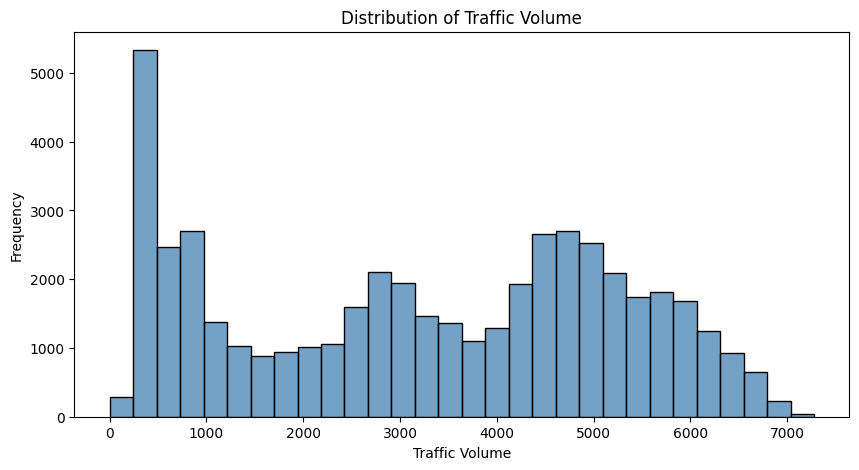

In [24]:
plt.figure(figsize=(10,5))
sns.histplot(df['traffic_volume'], bins=30, color='steelblue')

plt.title("Distribution of Traffic Volume")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")

plt.show()

### 12.2 Average Traffic Volume by Hour

This visualization shows how average traffic volume changes throughout the day, helping identify peak traffic hours.

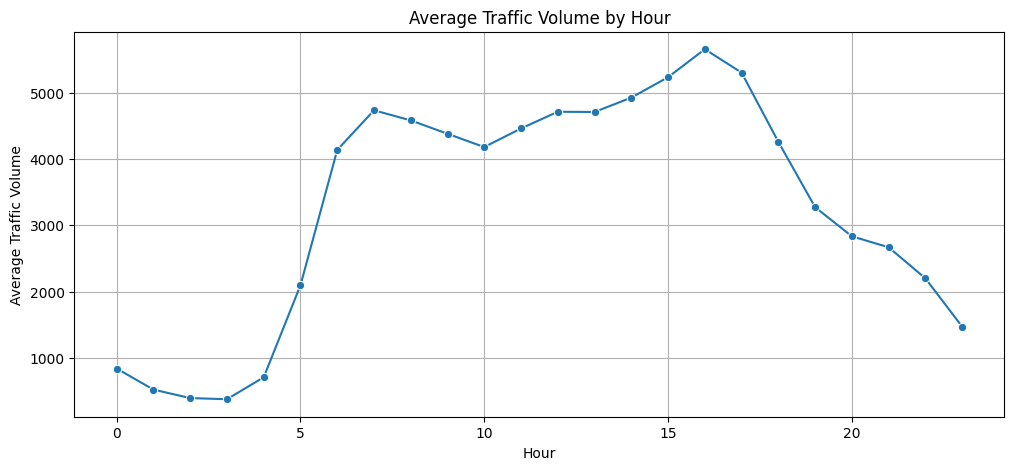

In [25]:
hourly = df.groupby('hour')['traffic_volume'].mean()

plt.figure(figsize=(12,5))
sns.lineplot(x=hourly.index, y=hourly.values, marker='o')

plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Traffic Volume")

plt.grid(True)

plt.show()

### 12.3 Average Traffic Volume by Day of the Week

This chart compares average traffic volume across different days of the week.

/tmp/ipykernel_2023/3788727977.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_avg.index, y=day_avg.values, palette="viridis")


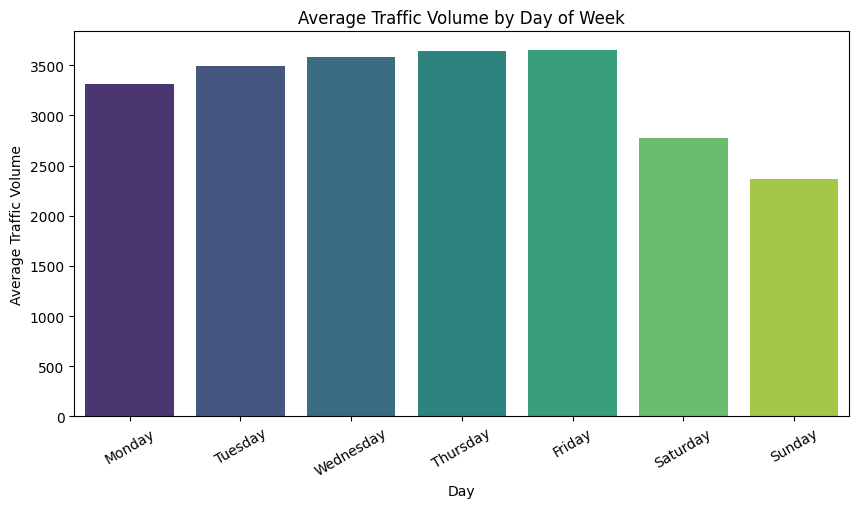

In [26]:
days = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

day_avg = df.groupby('day_of_week')['traffic_volume'].mean().reindex(days)

plt.figure(figsize=(10,5))
sns.barplot(x=day_avg.index, y=day_avg.values, palette="viridis")

plt.title("Average Traffic Volume by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Traffic Volume")

plt.xticks(rotation=30)

plt.show()

### 12.4 Average Traffic Volume by Weather Condition

This visualization compares average traffic volume under different weather conditions.

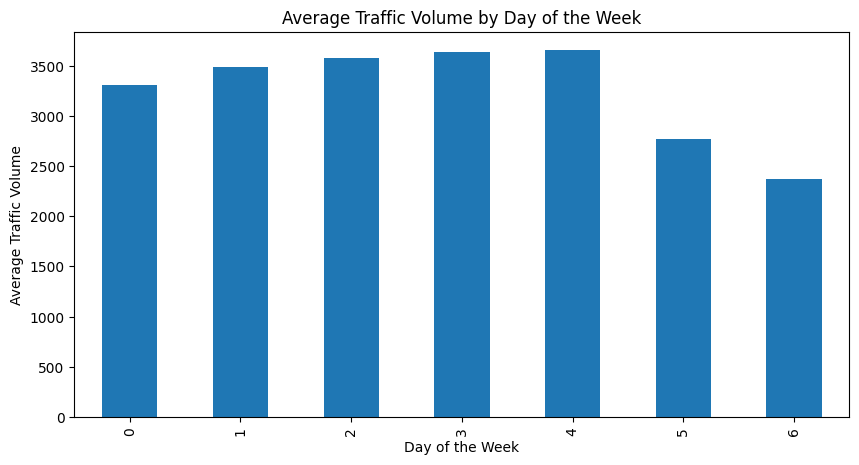

In [19]:
weather = df.groupby('weather_main')['traffic_volume'].mean().sort_values()

plt.figure(figsize=(12,5))
sns.barplot(x=weather.index, y=weather.values, palette="coolwarm")

plt.title("Average Traffic Volume by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Traffic Volume")

plt.xticks(rotation=45)

plt.show()

### 12.5 Temperature vs Traffic Volume

This scatter plot explores the relationship between temperature and traffic volume.

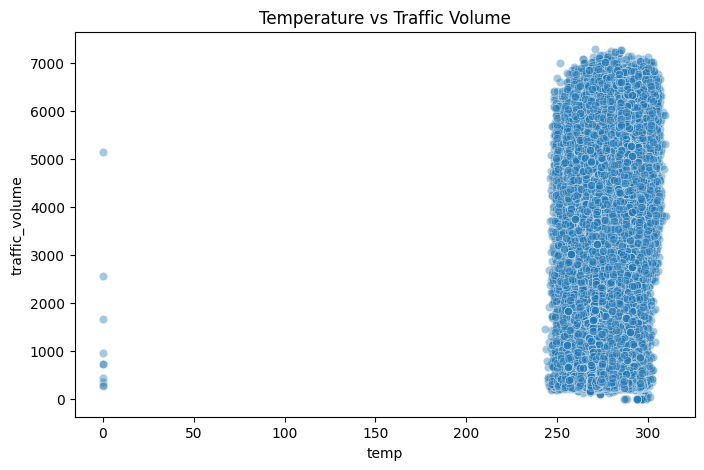

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='temp',
    y='traffic_volume',
    data=df,
    alpha=0.4
)

plt.title("Temperature vs Traffic Volume")

plt.show()

### 12.6 Correlation Heatmap

The heatmap displays the correlation between numerical variables in the dataset.

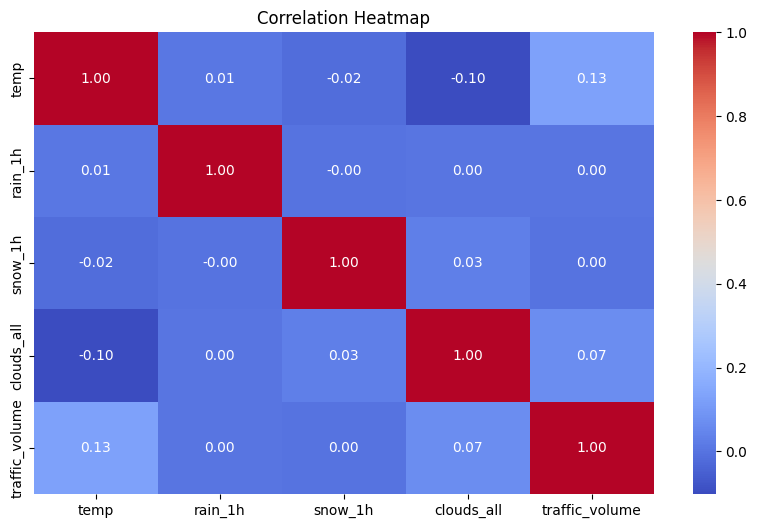

In [28]:
plt.figure(figsize=(10,6))

numeric = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## 13. Correlation Analysis

Correlation analysis helps identify the strength and direction of relationships between numerical variables in the dataset. It is useful for understanding which features may influence traffic volume.

### 13.1 Correlation Heatmap

The correlation heatmap visualizes the relationships between numerical features. Values closer to 1 indicate a strong positive correlation, while values closer to -1 indicate a strong negative correlation.

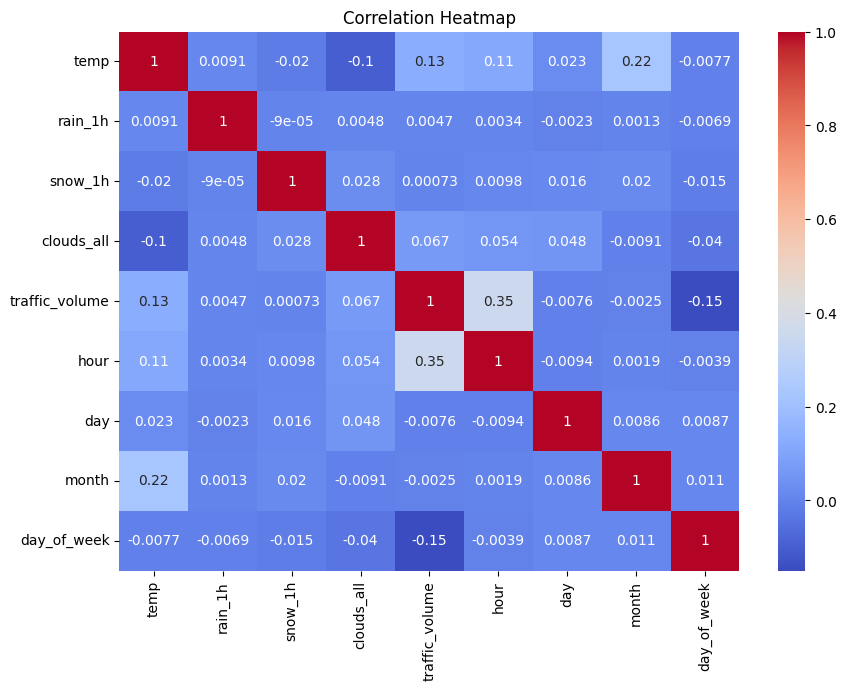

In [20]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 14. Prepare Data for Machine Learning

Before training machine learning models, the dataset is prepared by encoding categorical features, selecting relevant variables, and defining the target variable.

In [29]:
# Display current columns
df.columns

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume', 'hour', 'day',
       'month', 'day_of_week', 'year'],
      dtype='object')

## 15. Feature Selection

Relevant features are selected to predict traffic volume. Unnecessary columns such as detailed weather descriptions and the original date-time column are removed to improve model performance.

In [33]:
# One-Hot Encode categorical variables
df_ml = pd.get_dummies(
    df,
    columns=[
        'holiday',
        'weather_main',
        'weather_description',
        'day_of_week'
    ],
    drop_first=True
)

# Remove date_time
df_ml = df_ml.drop('date_time', axis=1)

# Features
X = df_ml.drop('traffic_volume', axis=1)

# Target
y = df_ml['traffic_volume']

print(X.shape)
print(y.shape)

(48187, 72)
(48187,)


## 16. Split the Dataset

The dataset is divided into training and testing sets. The training data is used to train the machine learning models, while the testing data is used to evaluate their performance on unseen data.

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (38549, 72)
Testing set: (9638, 72)


## 17. Machine Learning Model Development

In this section, we train multiple machine learning models to predict traffic volume.

The models will be compared based on their prediction performance.

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

lr = LinearRegression()
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
gb = GradientBoostingRegressor(
    random_state=42
)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

## 18. Model Evaluation

The trained models are evaluated using appropriate regression metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

In [36]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import pandas as pd

models = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

results = []

for name, model in models.items():

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = (mean_squared_error(y_test, pred))**0.5
    r2 = r2_score(y_test, pred)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R² Score"]
)

results_df

,Model,MAE,RMSE,R² Score
0,Linear Regression,1609.559065,4044.969634,-3.092567
1,Random Forest,201.934249,362.607450,0.967112
2,Gradient Boosting,387.347599,566.791599,0.919645


## 19. Model Comparison

The performance of the machine learning models is compared to identify the model that provides the best prediction results for traffic volume.

In [37]:
results_df.sort_values(
    by="R² Score",
    ascending=False
)

,Model,MAE,RMSE,R² Score
1,Random Forest,201.934249,362.607450,0.967112
2,Gradient Boosting,387.347599,566.791599,0.919645
0,Linear Regression,1609.559065,4044.969634,-3.092567


## Model Performance Analysis

The performance of different machine learning models was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

Among all tested models, the Random Forest Regressor achieved the best performance with an R² Score of 0.967, indicating that it explains approximately 96.7% of the variation in traffic volume.

The Random Forest model also produced the lowest MAE and RMSE values, making it the most suitable model for traffic volume prediction.

Linear Regression performed poorly because traffic patterns are influenced by complex non-linear relationships between time, weather, and other factors.

## 20. Traffic Volume Prediction

The best-performing machine learning model is used to generate traffic volume predictions on unseen test data.

In [38]:
best_model = rf

predictions = best_model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison.head(10)

,Actual,Predicted
0,4924,5005.71
1,3800,4012.70
2,5124,5255.80
3,4986,5506.75
4,4735,4231.52
5,3055,2575.60
6,1724,2028.54
7,4028,2809.14
8,3397,3447.73
9,5597,5375.96


### Actual vs Predicted Traffic Volume

This plot compares the actual traffic volume values with the values predicted by the Random Forest model.

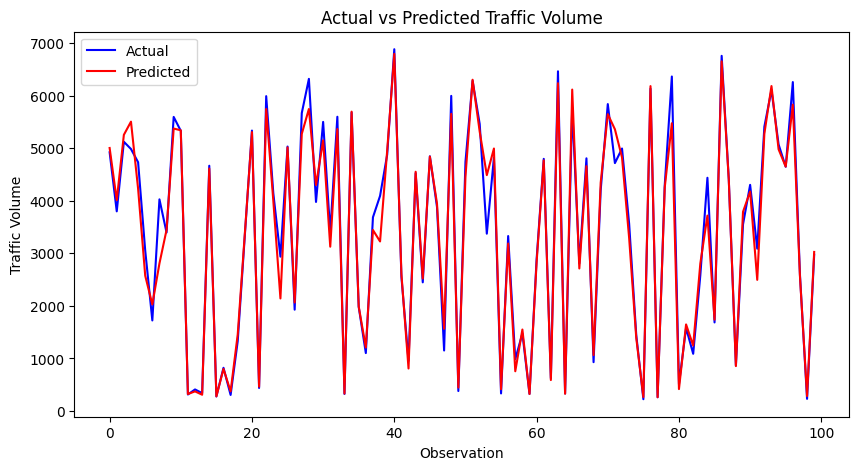

In [39]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test.values[:100],
    label="Actual",
    color="blue"
)

plt.plot(
    predictions[:100],
    label="Predicted",
    color="red"
)

plt.title("Actual vs Predicted Traffic Volume")
plt.xlabel("Observation")
plt.ylabel("Traffic Volume")

plt.legend()
plt.show()

## 21. Conclusion

This project analyzed urban traffic patterns and developed machine learning models to predict traffic volume.

The analysis explored the influence of time, weather conditions, and other factors on traffic patterns. Multiple machine learning models were trained and evaluated to determine the most suitable model for traffic volume prediction.

The results of the analysis can help demonstrate how data science and machine learning can be applied to real-world urban traffic problems.

## 22. Save the Trained Model

The best-performing model (Random Forest Regressor) is saved so that it can be reused for future traffic volume predictions without retraining.

In [42]:
import joblib
import gzip

with gzip.open("traffic_model_compressed.pkl.gz", "wb", compresslevel=9) as f:
    joblib.dump(rf, f)

print("Done")

Done
